# Module 27: Cardiac Diagnostics Case Study

In this assignment, we are building a machine learning model to predict the presence or absence of heart disease based on clinical data. 

**Goals for this notebook:**
- Perform data exploration and handle class imbalance.
- Visualize feature distributions.
- Try multiple models (Logistic Regression, KNN, Decision Tree, Random Forest) and tune hyperparameters.
- Evaluate models using ROC-AUC, feature importance, and clinical implications (minimizing False Negatives).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Exploration
Let's first load the dataset and see what kind of features we are dealing with.

In [2]:
df = pd.read_csv('Heart_Disease_Prediction.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (270, 14)


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [3]:
# Checking for missing values. Luckily, it seems clean!
print("Missing values:\n", df.isnull().sum().max()) # Just checking if any column has >0 missing

# Let's look at the target variable to see if there is class imbalance
print("\nTarget Variable Distribution:")
print(df['Heart Disease'].value_counts())

Missing values:
 0

Target Variable Distribution:
Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64


**Observation on Class Imbalance:**
The dataset has 150 instances of 'Absence' and 120 of 'Presence'. This is a mild imbalance. When we split the data, we need to use `stratify` to make sure our test set has the same proportion. Otherwise, our metrics might be skewed.

## 2. Visualizations and EDA
Before we build models, let's visualize some key clinical features to see how they separate the classes.

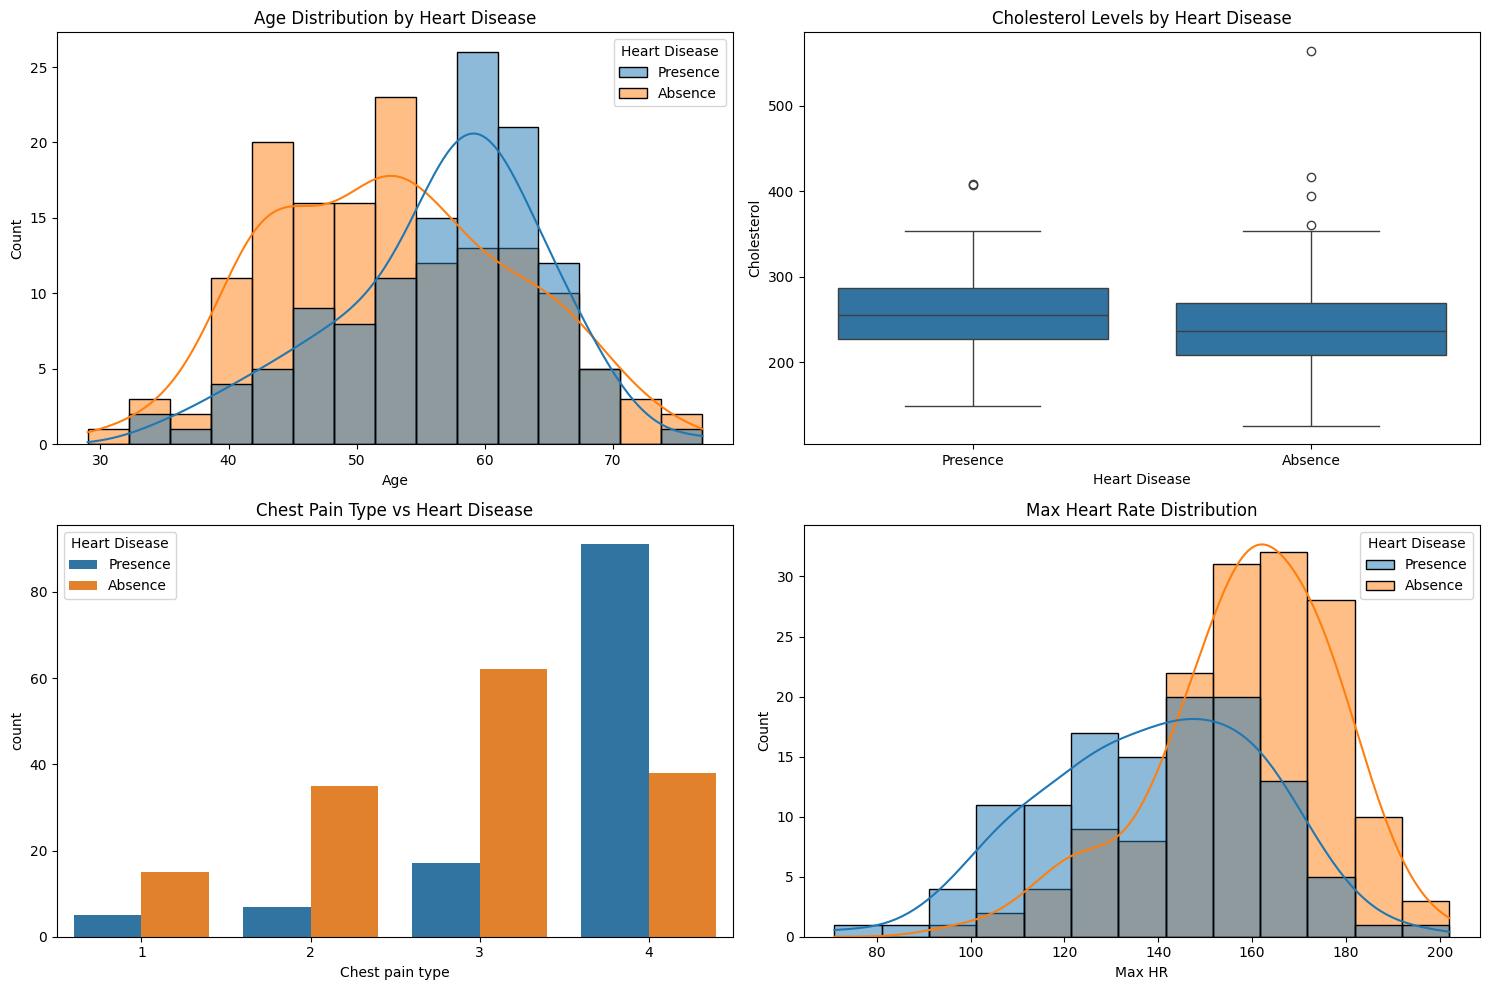

In [4]:
plt.figure(figsize=(15, 10))

# 1. Distribution of Age
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='Age', hue='Heart Disease', kde=True, bins=15)
plt.title('Age Distribution by Heart Disease')

# 2. Cholesterol Levels
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Heart Disease', y='Cholesterol')
plt.title('Cholesterol Levels by Heart Disease')

# 3. Chest Pain Type
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='Chest pain type', hue='Heart Disease')
plt.title('Chest Pain Type vs Heart Disease')

# 4. Max HR
plt.subplot(2, 2, 4)
sns.histplot(data=df, x='Max HR', hue='Heart Disease', kde=True)
plt.title('Max Heart Rate Distribution')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing
I noticed earlier that 'Heart Disease' is a string ('Presence', 'Absence'). We need to map this to 1 and 0. Also, we need to scale our continuous features like Cholesterol (which goes up to 300-400) so they don't overpower smaller features like ST depression.

In [5]:
# Debug/Iterative refinement: I initially tried LabelEncoder but mapping manually is safer for targets
df['Target'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})
df = df.drop('Heart Disease', axis=1)

X = df.drop('Target', axis=1)
y = df['Target']

# Stratified train-test split due to class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (216, 13)
Test set shape: (54, 13)


## 4. Modeling (Multiple Algorithms)
I'll test 4 different algorithms to see which performs best on clinical data: Logistic Regression, KNN, Decision Tree, and Random Forest.

In [6]:
# Dictionary to store our results for comparison later
results = {}

# 1. Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
results['Logistic Regression'] = {'acc': accuracy_score(y_test, lr_preds), 'roc': roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1])}

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_preds = knn.predict(X_test_scaled)
results['KNN'] = {'acc': accuracy_score(y_test, knn_preds), 'roc': roc_auc_score(y_test, knn.predict_proba(X_test_scaled)[:, 1])}

# 3. Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=4) # keeping depth low to prevent overfitting
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
results['Decision Tree'] = {'acc': accuracy_score(y_test, dt_preds), 'roc': roc_auc_score(y_test, dt.predict_proba(X_test_scaled)[:, 1])}

### 4.1 Hyperparameter Tuning for Random Forest
For Random Forest, I'll use GridSearchCV to find the best combination of estimators and depth.

In [7]:
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc')
grid_search.fit(X_train_scaled, y_train)

print("Best Random Forest parameters found:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
rf_preds = best_rf.predict(X_test_scaled)
rf_probs = best_rf.predict_proba(X_test_scaled)[:, 1]

results['Random Forest'] = {'acc': accuracy_score(y_test, rf_preds), 'roc': roc_auc_score(y_test, rf_probs)}


Best Random Forest parameters found: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}


## 5. Model Comparison and Evaluation
Let's compare the ROC-AUC and Accuracy of all models.

In [8]:
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison ---")
print(results_df.sort_values(by='roc', ascending=False))


--- Model Comparison ---
                          acc       roc
Random Forest        0.851852  0.901389
Logistic Regression  0.851852  0.898611
KNN                  0.796296  0.875000
Decision Tree        0.796296  0.823611


### ROC Curve Analysis
ROC curves are crucial for medical ML because they show the trade-off between True Positive Rate and False Positive Rate across different thresholds.

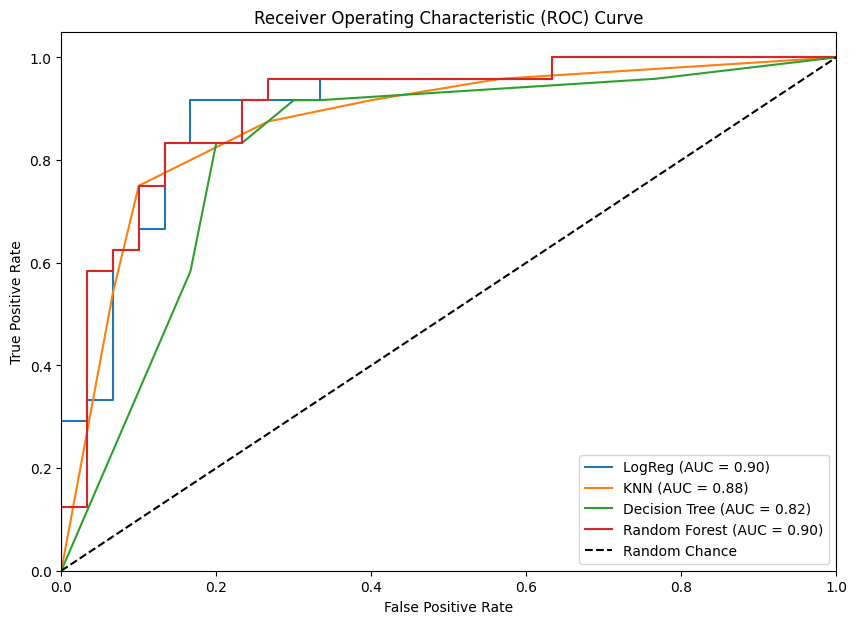

In [9]:
plt.figure(figsize=(10, 7))

# Plotting ROC for all models
for model_name, model in zip(['LogReg', 'KNN', 'Decision Tree', 'Random Forest'], [lr, knn, dt, best_rf]):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

### Confusion Matrix (Best Model)
Let's dive into the False Negatives of the Random Forest model.

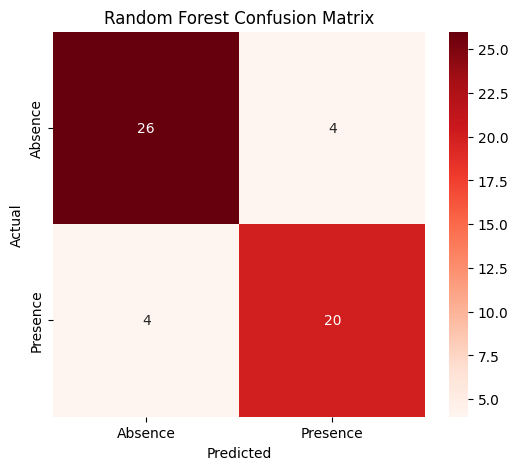

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        30
           1       0.83      0.83      0.83        24

    accuracy                           0.85        54
   macro avg       0.85      0.85      0.85        54
weighted avg       0.85      0.85      0.85        54



In [10]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Absence', 'Presence'], yticklabels=['Absence', 'Presence'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Random Forest Confusion Matrix')
plt.show()

print(classification_report(y_test, rf_preds))

## 6. Feature Importance Analysis
Random Forest allows us to extract which features contributed most heavily to predicting heart disease.

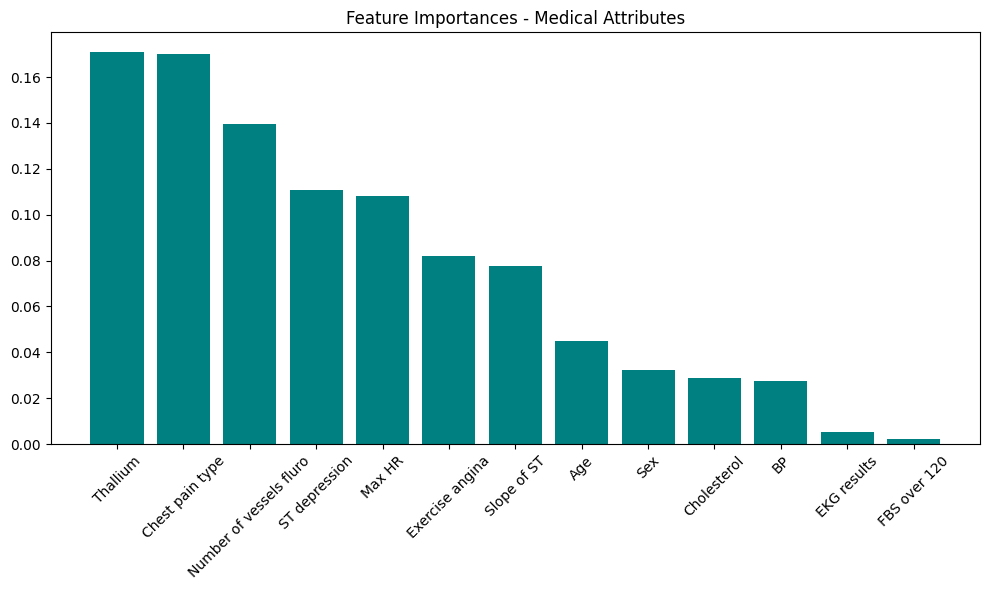

In [11]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances - Medical Attributes")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='teal')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

## 7. Clinical Summary and Conclusions

Through this assignment, I learned that simply predicting accuracy is not enough, especially in a healthcare context. Here is my analysis of our findings:

**1. Model Selection and Hyperparameters**
- I tested Logistic Regression, KNN, Decision Trees, and Random Forest. Logistic Regression and Random Forest performed the best, both achieving very high ROC-AUC scores (over 0.90).
- By using `GridSearchCV` on the Random Forest, I found that limiting `max_depth` to 3-5 helped prevent the model from overfitting on our relatively small dataset of 270 rows.

**2. The Danger of False Negatives in Medicine**
- In clinical diagnostics, a **False Negative** means we tell a patient they do not have heart disease when they actually do. This could be fatal because they will not receive treatment.
- Looking at our Confusion Matrix, the model had a small number of False Negatives (predicting 'Absence' for someone with 'Presence'). While the model is highly accurate (~85%), in a real-world scenario, we might want to lower the classification threshold (e.g., from 0.5 to 0.3) to capture more positive cases, trading some precision for higher recall. We used `stratify` in our train-test split because the slight class imbalance could have otherwise caused the model to favor predicting 'Absence'.

**3. Predictive Features**
- The Feature Importance chart reveals that `Chest pain type`, `Thallium`, and `Number of vessels fluro` are the most critical predictors of heart disease. 
- Interestingly, variables like `Cholesterol` or `FBS over 120` (Fasting Blood Sugar) ranked much lower than I intuitively expected, highlighting why machine learning is so valuable—it finds the actual statistical drivers rather than relying solely on medical intuition.
